# Premières étapes
## Import des packages

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from alibi.explainers import ALE, plot_ale
import lime
import lime.lime_tabular
from IPython.display import display, HTML
import shap

c:\Users\isali\Documents\cours\M2_ECAP\SVM_projet\projet_svm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import des données

In [4]:
df = pd.read_csv('data/raw/StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# Vérification des doublons
print(df.duplicated().sum())

# Infos sur les données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

Pas de doublons.
6607 observations, 18 variables explicatives pour 1 variable cible : Exam_Score.
Les types des variables semblent bien correspondre aux données.
On constate la présence de valeurs manquantes dans Teacher_Quality, Parental_Education_Level, et Distance_From_Home.

## Création de listes de variables en fonction du type

In [ ]:
# Colonnes quantitatives (numériques)
num_cols = df.select_dtypes(include=['int64']).columns.tolist()

# Colonnes qualitatives catégorielles (texte)
cat_cols = df.select_dtypes(include=['str']).columns.tolist()

# Nettoyage et visualisation des données

## Création d'une palette de couleurs

In [34]:
palette = sns.color_palette("pastel", 10)

## Analyse descriptives univariées
### Variables numériques

In [ ]:
# Statistiques descriptives
df.describe() 

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


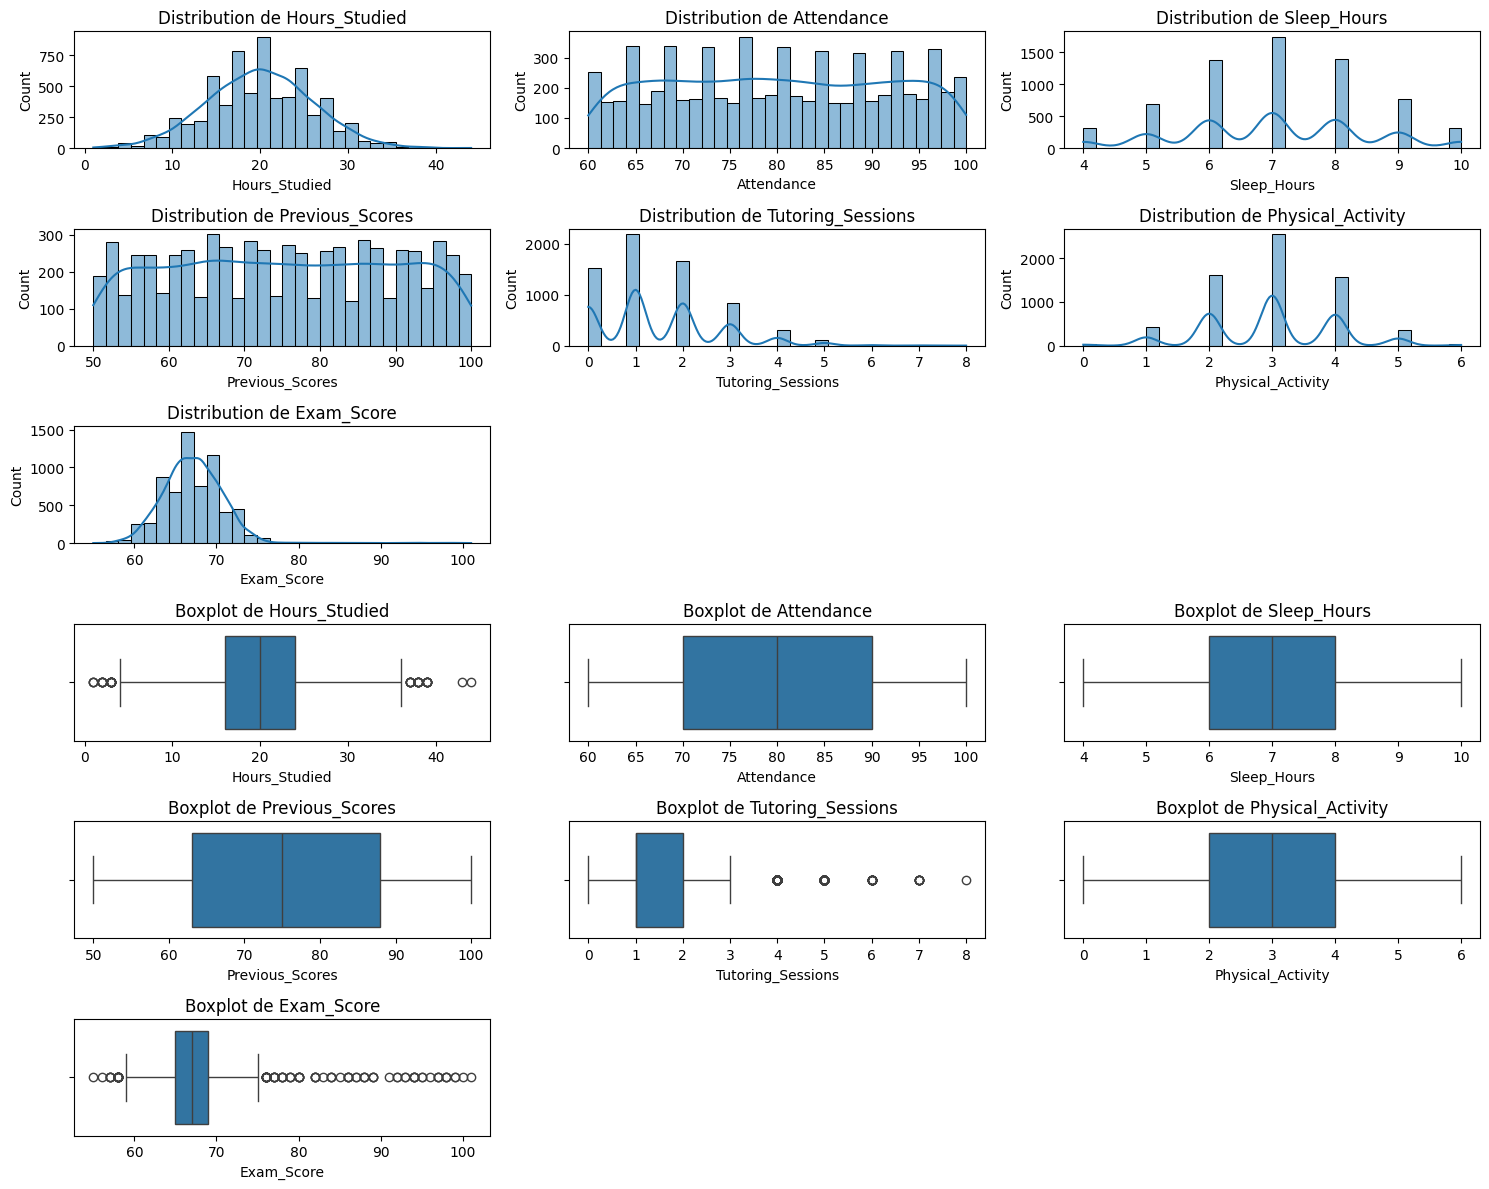

In [ ]:
# Histogrammes et Boxplots 

num_cols = df.select_dtypes(include=[np.number]).columns
n_vars = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    2 * n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, col in enumerate(num_cols):
    # Indices de ligne / colonne
    row = i // n_cols
    col_idx = i % n_cols

    # Histogramme
    ax_hist = axes[row, col_idx]
    sns.histplot(df[col], bins=30, kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution de {col}")

    # Boxplot
    ax_box = axes[row + n_rows, col_idx]
    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot de {col}")

# Masque les axes vides
for j in range(n_vars, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes[r, c].axis("off")
    axes[r + n_rows, c].axis("off")

plt.tight_layout()
plt.show()

Les distributions des variables quantitatives semblent suivre la Loi Normale, à l'exception de *Attendance* et *Hours_Studied*.
On observe la présence de potentielles valeurs extrêmes dans *Hours_Studied*, *Tutoring_Sessions*, et *Exam_Score*.

### Variables catégorielles

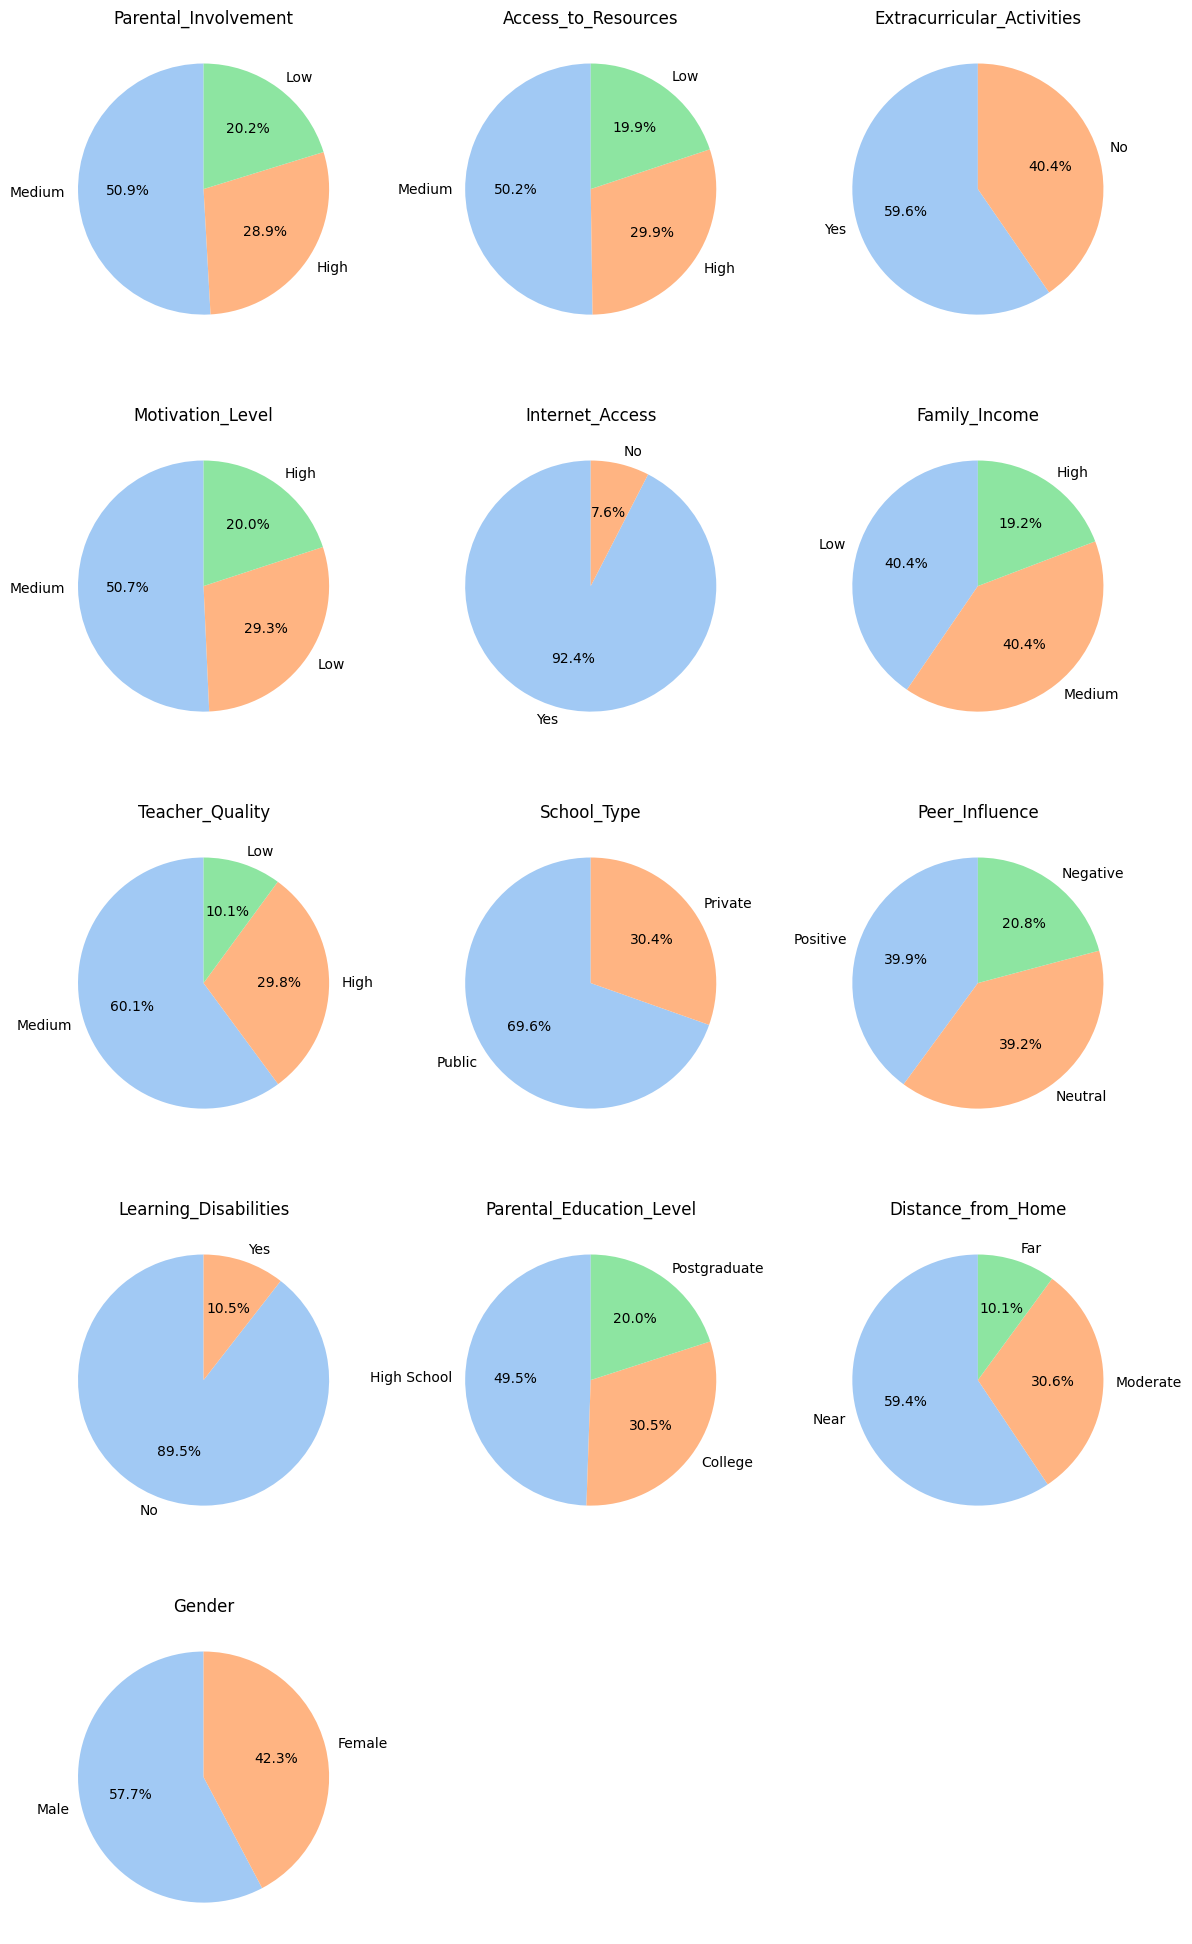

In [35]:
# Pie Chart pour variables catégorielles
def plot_pie(columns):

    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        counts = df[col].value_counts()

        axes[i].pie(
            counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=palette
        )

        axes[i].set_title(col)

    # Suppression des axes inutilisés
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Affichage 
plot_pie(cat_cols)

Les variables catégorielles ne montrent pas la présence de modalités avec un très faible pourcentage de valeurs (< 5% par exemple), auquel cas nous aurions pu avoir à regrouper certaines catégories entre elles pour améliorer la performance des modèles. 

### Traitement des valeurs manquantes

In [36]:
df.isna().sum(axis=0)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [ ]:
# Colonnes avec valeurs manquantes
missing_cols = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

# Imputation avec la modalité la plus fréquente
cat_imputer = SimpleImputer(strategy="most_frequent")

df[missing_cols] = cat_imputer.fit_transform(df[missing_cols])

In [ ]:
# Vérification des valeurs manquantes après imputation
print(df.isna().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


### Corrélations entre variables explicatives numériques

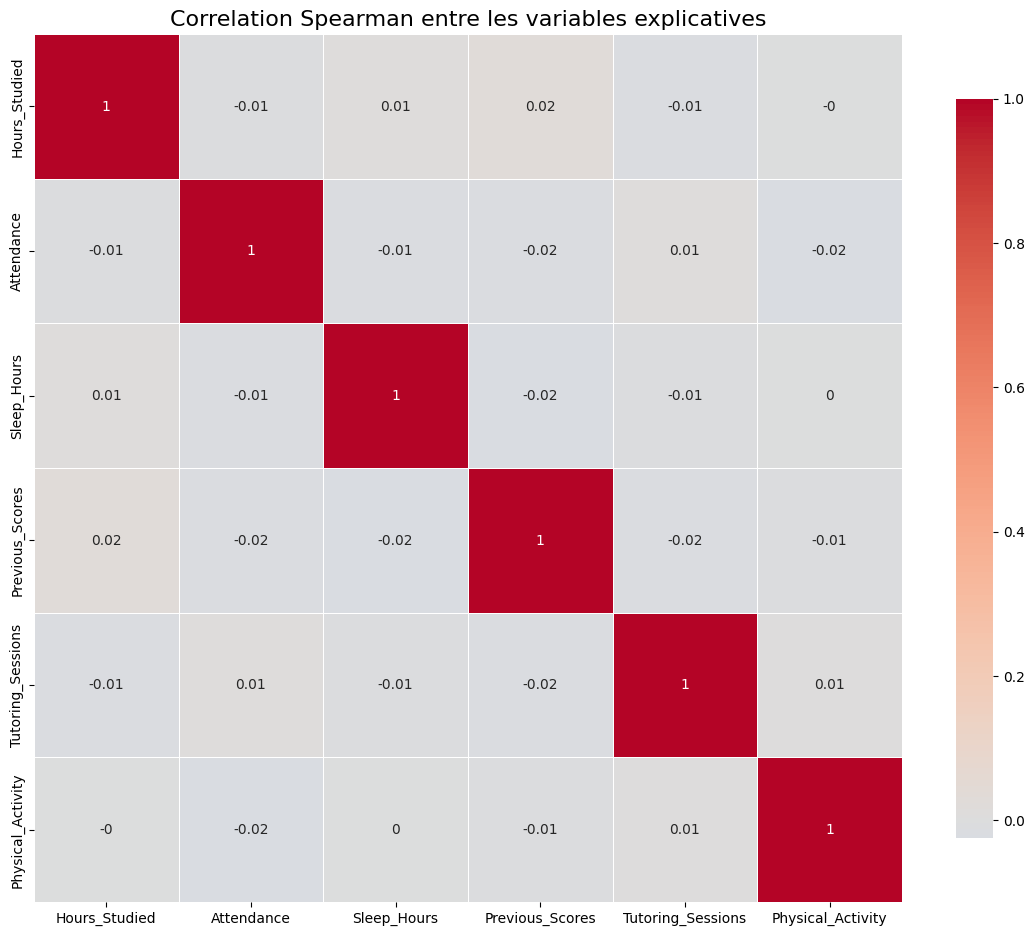

In [39]:
# Correlation map avec spearman entre les variables explicatives
# Exclusion de la variable cible
x_cols = [c for c in num_cols if c != "Exam_Score"]

# Application de la méthode de corrélation de Spearman
corr = df[x_cols].corr(method='spearman')

# Figure
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=corr.round(2), cmap="coolwarm", center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation Spearman entre les variables explicatives", fontsize=16)
plt.show()

Le jeu de données étant fictif, nous retrouvons uniquement des corrélations quasiment inexistante. Cela ne pose pas de problème pour la réalisation de modèles de regréssions mais cela limite néanmoins le réalisme de ce dataset et donc des résultats que nous obtiendrons.

### Corrélation entre variables qualitatives

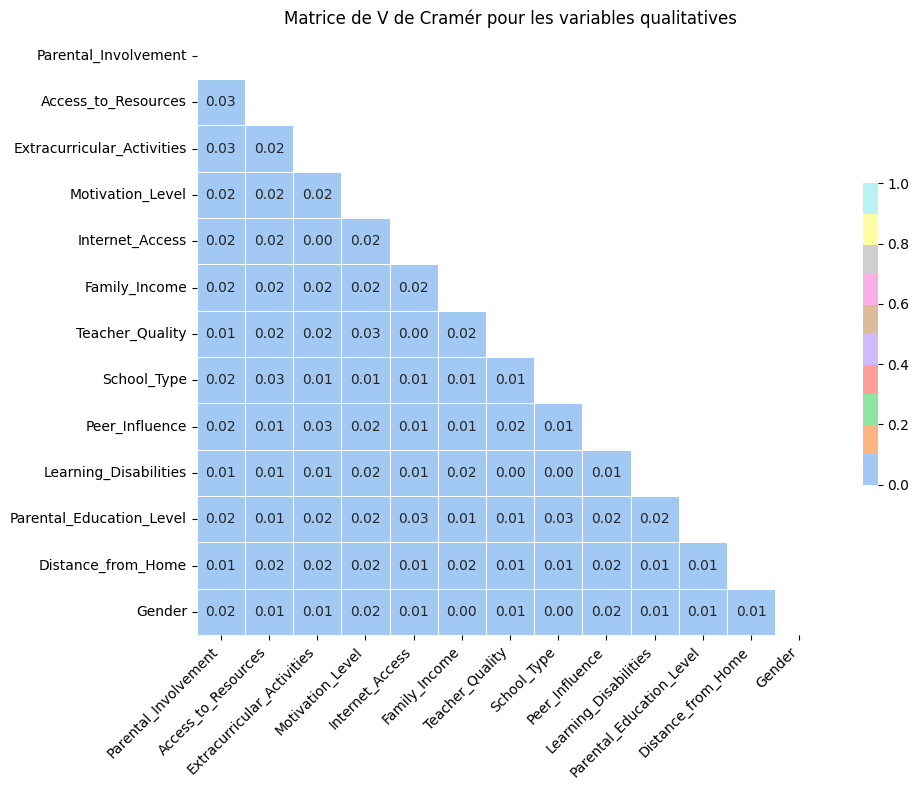

In [ ]:
# Matrice de V de Cramer sous forme de heatmap

# Création de la matrice de V de Cramer
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

cramer_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

## Figure et Heatmap
### Masque pour le triangle supérieur
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))

### Affichage
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramer_matrix.astype(float),
    mask=mask,
    cmap=palette,
    vmin=0,
    vmax=1,
    center=0.5,
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": 0.5},
    annot_kws={"size": 10}
)

plt.title("Matrice de V de Cramér pour les variables qualitatives")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

De la même façon que pour les variables numériques, il n'existe que des corrélations extremement faibles entre les variables qualitatives. 
Dans le cas inverse, nous aurions pu sélectionner les variables à inclure dans notre modèle de telle sorte à ce qu'il n'existe pas de variables fortement corrélées entre elles. Cela pourrait notamment se faire en supprimant une à une les variables les plus corrélées à d'autres, puis en recalculant les corrélations après chaque suppression, jusqu'à ce qu'il n'existe plus de corrélations fortes, supérieures à 0,8 ou 0,7. 

### Analyse des relations entre variables quantitatives et la variables cible

C:\Users\isali\AppData\Local\Temp\ipykernel_6968\47652511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)
C:\Users\isali\AppData\Local\Temp\ipykernel_6968\47652511.py:5: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)


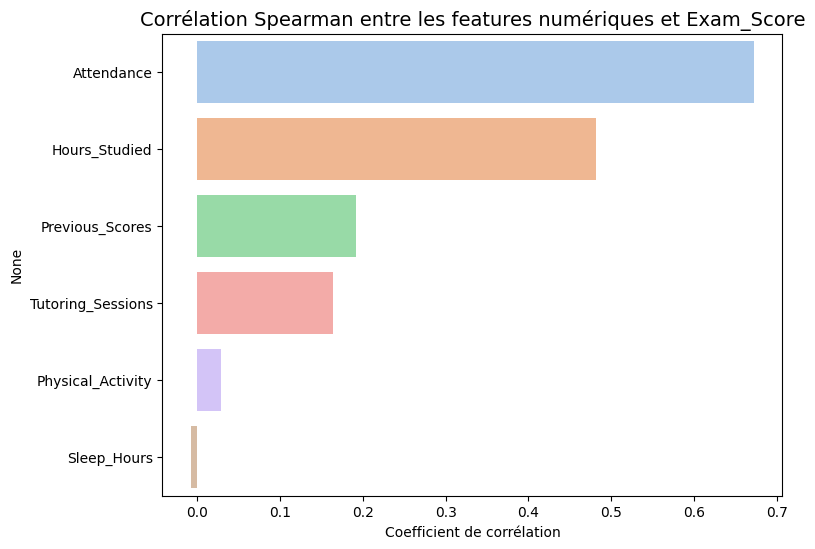

In [48]:
# Corrélation entre les variables explicatives numériques et la variable cible
corr_target = df[x_cols + ["Exam_Score"]].corr(method="spearman")["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)
plt.title("Corrélation Spearman entre les features numériques et Exam_Score", fontsize=14)
plt.xlabel("Coefficient de corrélation")
plt.show()

## Analyse descriptive multivariée
### Analyse des relations entre variables qualitatives et la variable cible

C:\Users\isali\AppData\Local\Temp\ipykernel_6968\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_6968\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_6968\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_6968\1519432884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

<Figure size 1400x3000 with 0 Axes>

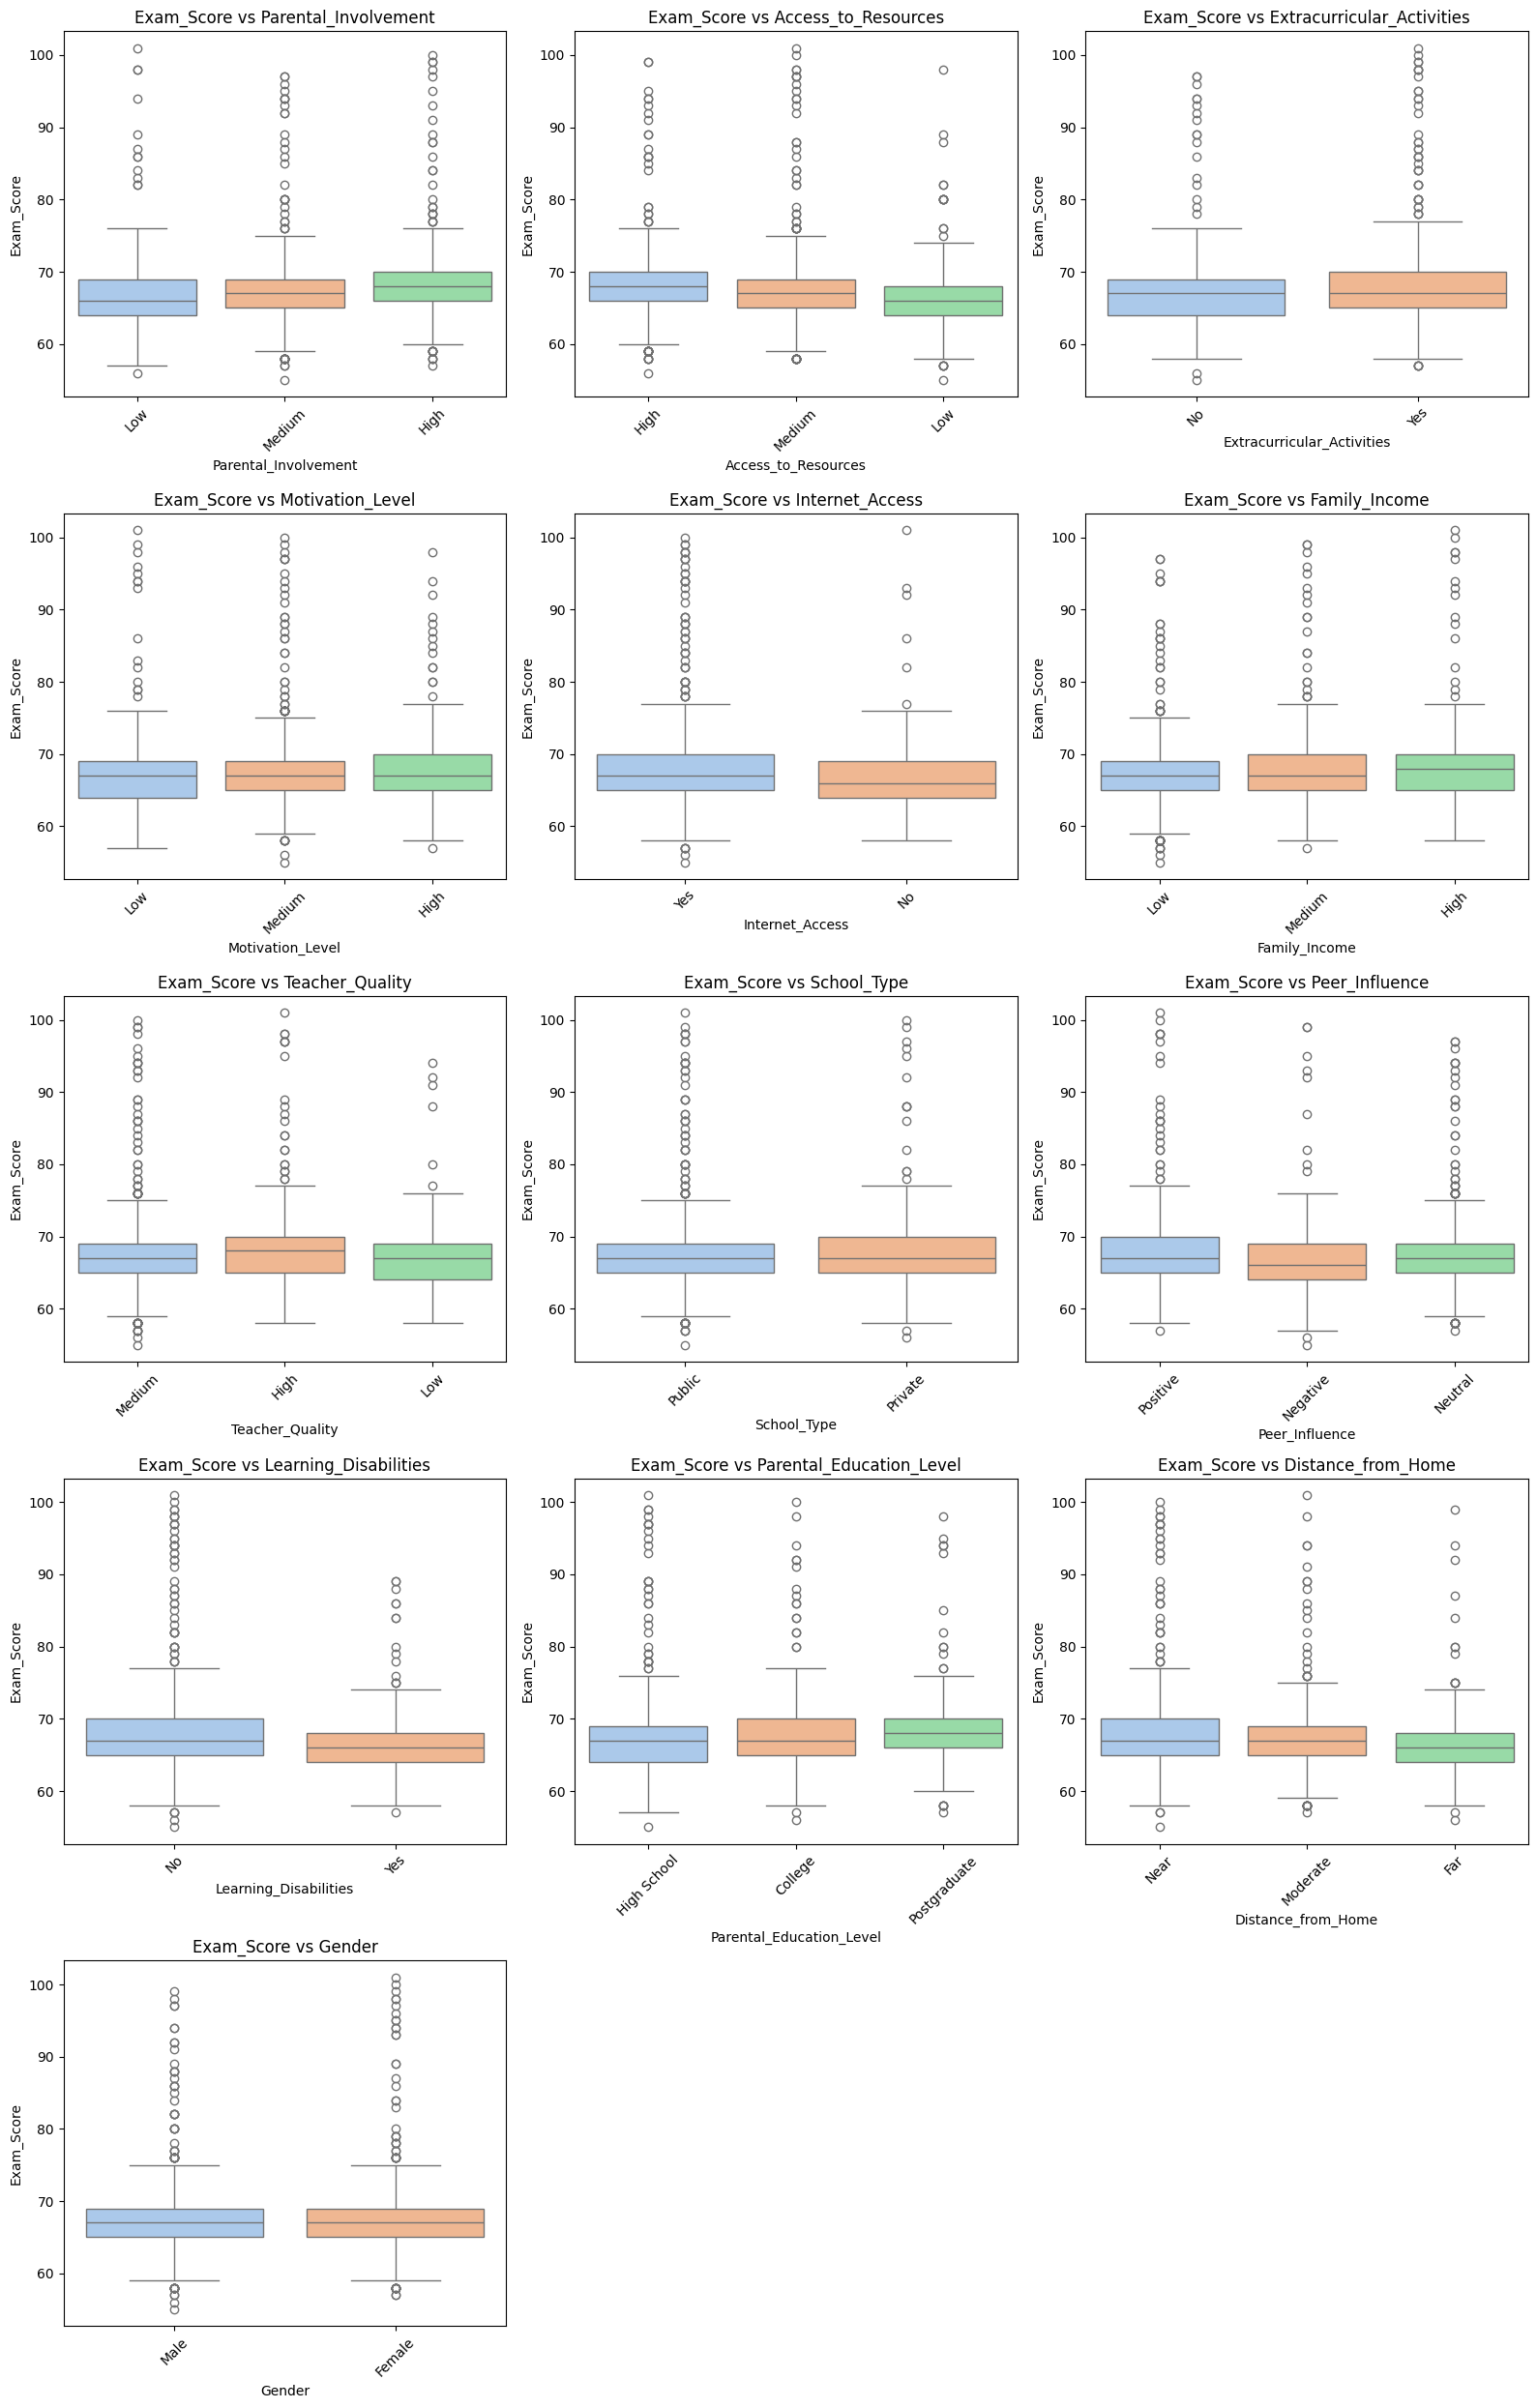

In [47]:
plt.figure(figsize=(14, 30))

# Nombre de variables qualitatives
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten()

for i, cat in enumerate(cat_cols):
    sns.boxplot(
        data=df,
        x=cat,
        y="Exam_Score",
        ax=axes[i],
        palette="pastel"
    )
    axes[i].set_title(f"Exam_Score vs {cat}")
    axes[i].tick_params(axis="x", rotation=45)

# Supprimer les axes vides si le nombre de sous-plots dépasse le nombre de variables
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Traitements avant modélisation
## Train test split
### Séparation

In [ ]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Vérification de l'équilibre de la variable cible après le split

In [ ]:
# Vérification sur variables numériques
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Train
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("Distribution Train")
axes[0].set_xlabel("Exam Score")

# Test
sns.histplot(y_test, kde=True, ax=axes[1])
axes[1].set_title("Distribution Test")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.show()

La distribution de la variable cible semble bien équilibrée entre le jeu train et le jeu test. Le jeu test est ainsi une bonne représentation du jeu train pour la régression.

## Feature Engineering

## Winsorization des valeurs extrêmes
Pour éviter le data leakage, on calcule les quantiles uniquement sur le jeu d'entraînement, puis on appliquera sur le jeu test.

In [49]:
quantiles = {}

for col in X_train.columns:
    low = X_train[col].quantile(0.01)
    high = X_train[col].quantile(0.99)
    quantiles[col] = (low, high)

def apply_winsorization(df, quantiles):
    df = df.copy()
    for col, (low, high) in quantiles.items():
        df[col] = df[col].clip(low, high)
    return df

# Application de la winsorization sur les jeux d'entraînement et de test
X_train = apply_winsorization(X_train, quantiles)
X_test  = apply_winsorization(X_test, quantiles)

AttributeError: 'Series' object has no attribute 'columns'

## Transformation 
(après winsorization pour éviter que les valeurs extrêmes faussent la transformation)

## Normalisation des features

scaler = StandardScaler()
scaler.fit(X_train_rl)

X_train_sc = scaler.transform(X_train_rl)
X_test_sc = scaler.transform(X_test_rl)

print(X_train_sc.shape, X_test_sc.shape, y_train.shape, y_test.shape)